# Empirical Finance - Project 1

Jack Feen, Humphrey Hui, Michael Ovassapian

In [63]:
import wrds
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

db = wrds.Connection()

Loading library list...
Done


## Compustat Query - Get R&D Data

In [65]:
compustat = db.raw_sql("""
SELECT
    gvkey,
    datadate,
    xrd
FROM comp.funda
WHERE datadate BETWEEN '1974-01-01' AND '2022-12-31'
    AND curcd = 'USD'
    AND fic = 'USA'
    AND exchg BETWEEN 11 AND 19
    AND indfmt = 'INDL'
    AND datafmt = 'STD'
    AND consol = 'C'
    AND popsrc = 'D'
    AND (sich < 6000 OR sich > 6999 OR sich IS NULL)
    AND (sich != 2834 OR sich IS NULL)
""", date_cols=['datadate'])

# Clean xrd: coerce to numeric, set negatives to NaN
compustat['xrd'] = pd.to_numeric(compustat['xrd'], errors='coerce')
compustat.loc[compustat['xrd'] < 0, 'xrd'] = np.nan

compustat.head()

,gvkey,datadate,xrd
0,001000,1974-12-31,<NA>
1,001000,1975-12-31,<NA>
2,001000,1976-12-31,<NA>
3,001000,1977-12-31,<NA>
4,001001,1978-12-31,<NA>


## CCM Link - Compustat to CRSP

In [67]:
gvkey_list = "','".join(compustat['gvkey'].unique().astype(str))
ccm = db.raw_sql(f"""
SELECT 
    gvkey, 
    lpermno AS permno, 
    linkdt, 
    COALESCE(linkenddt, CURRENT_DATE) AS linkenddt
FROM crsp.ccmxpf_lnkhist
WHERE linktype IN ('LU', 'LC') 
    AND linkprim IN ('P', 'C')
    AND gvkey IN ('{gvkey_list}')
""", date_cols=['linkdt', 'linkenddt'])

## CRSP Query - Monthly Returns

In [69]:
permno_list = ",".join(ccm['permno'].unique().astype(str))

crsp = db.raw_sql(f"""
SELECT
    a.permno,
    a.permco,
    a.date,
    a.ret,
    ABS(a.prc) * a.shrout AS me,
    b.siccd
FROM crsp.msf a
INNER JOIN crsp.msenames b
    ON a.permno = b.permno
    AND a.date BETWEEN b.namedt AND b.nameendt
WHERE a.date BETWEEN '01/01/1980' AND '12/31/2022'
    AND a.permno IN ({permno_list})
    AND b.shrcd IN (10, 11)
    AND b.exchcd IN (1, 2, 3)
    AND (b.siccd < 6000 OR b.siccd > 6999 OR b.siccd IS NULL)
    AND (b.siccd != 2834 OR b.siccd IS NULL)
""", date_cols=['date'])

# Clean returns
crsp['ret'] = pd.to_numeric(crsp['ret'], errors='coerce')
crsp['siccd'] = pd.to_numeric(crsp['siccd'], errors='coerce')
crsp = crsp[crsp['ret'].notna() & (crsp['ret'] >= -1)].copy()

crsp.head()

,permno,permco,date,ret,me,siccd
1,10000,7952,1986-02-28,-0.257143,11960.0,3990
2,10000,7952,1986-03-31,0.365385,16330.0,3990
3,10000,7952,1986-04-30,-0.098592,15172.0,3990
4,10000,7952,1986-05-30,-0.222656,11793.87834,3990
5,10000,7952,1986-06-30,-0.005025,11734.59375,3990


## CRSP Delisting Returns

In [71]:
dlret = db.raw_sql(f"""
SELECT 
    permno, 
    dlret, 
    dlstdt
FROM crsp.msedelist
WHERE permno IN ({permno_list})
""", date_cols=['dlstdt'])

dlret.head()

,permno,dlret,dlstdt
0,10000,0.0,1987-06-11
1,10001,0.011583,2017-08-03
2,10002,0.046007,2013-02-15
3,10003,0.01373,1995-12-15
4,10005,0.125,1991-07-11


## Fama-French Factors from WRDS

In [73]:
# FF Factors from WRDS
ff = db.get_table(library='ff', table='factors_monthly')[['date', 'mktrf', 'smb', 'hml', 'rf', 'year']]
ff['date'] = pd.to_datetime(ff['date']) + pd.offsets.MonthEnd(0)   # ensure month-end
ff = ff[ff['year']>1979]
ff = ff[ff['year']<2023]
ff = ff.drop(columns=['year'])
for col in ['mktrf', 'smb', 'hml', 'rf']:
    ff[col] = pd.to_numeric(ff[col], errors='coerce')

ff.head()

,date,mktrf,smb,hml,rf
642,1980-01-31,0.055,0.0162,0.0185,0.008
643,1980-02-29,-0.0123,-0.0186,0.0059,0.0089
644,1980-03-31,-0.129,-0.067,-0.0096,0.0121
645,1980-04-30,0.0395,0.0105,0.0103,0.0126
646,1980-05-31,0.0526,0.0205,0.0038,0.0081


## Adjust for Delisting Returns

In [75]:
# Prepare delisting returns
dlret['date'] = dlret['dlstdt'] + pd.offsets.MonthEnd(0)
dlret['dlret'] = pd.to_numeric(dlret['dlret'], errors='coerce')
dlret = dlret[['permno', 'date', 'dlret']].copy()

# Merge delisting returns with CRSP
crsp = pd.merge(crsp, dlret, on=['permno', 'date'], how='outer')

# Compound only when dlret exists; otherwise keep original return
crsp['ret_eff'] = np.where(crsp['dlret'].notna(),
                           (1 + crsp['ret'].fillna(0)) * (1 + crsp['dlret']) - 1,
                           crsp['ret'])

crsp = crsp[crsp['ret_eff'].notna() & (crsp['me'] > 0)].copy()

## PERMCO Aggregation - Firm-Level Market Equity

In [77]:
# Collapse to firm-level ME (PERMCO aggregation)
crsp_summe = crsp.groupby(['date', 'permco'])['me'].sum().reset_index().rename(columns={'me': 'me_firm'})
crsp = crsp.sort_values(['date', 'permco', 'me'], ascending=[True, True, False])
crsp = crsp.drop_duplicates(subset=['date', 'permco'], keep='first')
crsp = pd.merge(crsp, crsp_summe, on=['date', 'permco'], how='left')
crsp['me'] = crsp['me_firm']
crsp = crsp.drop(columns=['me_firm', 'permco'])

## Link Compustat to CRSP, Build Weighted R&D, and Apply Fama-French Timing

In [79]:
# Link Compustat to CRSP via CCM
comp = pd.merge(compustat, ccm, on='gvkey', how='inner')
comp = comp[(comp['datadate'] >= comp['linkdt']) & (comp['datadate'] <= comp['linkenddt'])]

# Build weighted R&D: xrd_w = 1.0*xrd_t + 0.8*xrd_{t-1} + 0.6*xrd_{t-2} + 0.4*xrd_{t-3} + 0.2*xrd_{t-4}
comp = comp.sort_values(['permno', 'datadate'])
comp['xrd_fill'] = comp['xrd'].fillna(0).clip(lower=0)
for i in range(1, 5):
    comp[f'xrd_lag{i}'] = comp.groupby('permno')['xrd_fill'].shift(i)
comp['xrd_w'] = (1.0 * comp['xrd_fill']
               + 0.8 * comp['xrd_lag1'].fillna(0)
               + 0.6 * comp['xrd_lag2'].fillna(0)
               + 0.4 * comp['xrd_lag3'].fillna(0)
               + 0.2 * comp['xrd_lag4'].fillna(0))

# Fama-French timing: fiscal year-end in calendar year t -> portfolio held July t+1 to June t+2
comp['portfolio_year'] = comp['datadate'].dt.year + 1
comp = comp.drop_duplicates(subset=['permno', 'portfolio_year'], keep='last')

# Extract June market cap from CRSP for R&D intensity scaling
# June of year t is the denominator for portfolios formed July t (portfolio_year = t)
# Convert me from thousands to millions to match Compustat xrd units
june_me = crsp[crsp['date'].dt.month == 6][['permno', 'date', 'me']].copy()
june_me['portfolio_year'] = june_me['date'].dt.year
june_me = june_me.drop(columns=['date'])
june_me['me'] = june_me['me'] / 1000  # thousands -> millions
june_me = june_me.rename(columns={'me': 'me_june'})
june_me = june_me.drop_duplicates(subset=['permno', 'portfolio_year'], keep='last')

# Merge June market cap and compute R&D intensity (xrd_w / ME_june)
comp = pd.merge(comp, june_me, on=['permno', 'portfolio_year'], how='left')
comp['rd_intensity'] = comp['xrd_w'] / comp['me_june']
# Rows with missing/zero me_june get NaN intensity -> will be sorted into RD_Zero

# Verify no duplicates in june_me caused a many-to-many merge
assert comp.duplicated(subset=['permno', 'portfolio_year']).sum() == 0, \
    "Duplicate (permno, portfolio_year) detected after june_me merge!"

## Construct Weighted R&D and Assign Quintile Portfolios

In [81]:
# Assign quintiles based on R&D intensity (xrd_w / ME_june), once per portfolio_year (annual sort)
def assign_quintiles_annual(group):
    pos = group['rd_intensity'] > 0
    group['portfolio'] = 'RD_Zero'
    if pos.sum() > 0:
        group.loc[pos, 'portfolio'] = pd.qcut(
            group.loc[pos, 'rd_intensity'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
        ).astype(str)
    return group

comp = comp.groupby('portfolio_year', group_keys=False).apply(assign_quintiles_annual)

## Assign Portfolio Years to CRSP and Lag Market Cap

In [83]:
# Assign CRSP months to FF portfolio years (July t to June t+1 = portfolio_year t)
crsp['month'] = crsp['date'].dt.month
crsp['year'] = crsp['date'].dt.year
crsp['portfolio_year'] = np.where(crsp['month'] >= 7, crsp['year'], crsp['year'] - 1)

# Lag market cap by one month
crsp = crsp.sort_values(['permno', 'date'])
crsp['me_lag'] = crsp.groupby('permno')['me'].shift(1)

## Merge CRSP with Portfolio Assignments and FF Factors

In [85]:
# Merge CRSP with Compustat portfolio assignments
comp_for_merge = comp[['permno', 'portfolio_year', 'portfolio']].copy()
df = pd.merge(crsp, comp_for_merge, on=['permno', 'portfolio_year'], how='inner')
df = df.dropna(subset=['me_lag'])
df = df[df['me_lag'] > 0]

# Merge FF factors
df = pd.merge(df, ff, on='date', how='left')
df = df.dropna(subset=['mktrf', 'rf', 'smb', 'hml'])

df.head()

,permno,date,ret,me,siccd,dlret,ret_eff,month,year,portfolio_year,me_lag,portfolio,mktrf,smb,hml,rf
0,10001,1987-07-31,0.021277,5946.0,4920,<NA>,0.021277,7,1987,1987,5822.125,RD_Zero,0.0384,-0.0057,0.0094,0.0046
1,10001,1987-08-31,0.083333,6441.5,4920,<NA>,0.083333,8,1987,1987,5946.0,RD_Zero,0.0352,-0.0085,-0.0098,0.0047
2,10001,1987-09-30,-0.022308,6200.0,4920,<NA>,-0.022308,9,1987,1987,6441.5,RD_Zero,-0.0258,0.0058,0.0026,0.0045
4,10001,1987-11-30,-0.029412,6138.0,4920,<NA>,-0.029412,11,1987,1987,6324.0,RD_Zero,-0.0776,0.0268,0.0314,0.0035
5,10001,1987-12-31,-0.033535,5828.0,4920,<NA>,-0.033535,12,1987,1987,6138.0,RD_Zero,0.0682,0.0003,-0.0442,0.0039


## Calculate Portfolio Returns (EW and VW)

In [87]:
# --- Two sample versions ---
# Sample 1: All firms (no ME filter)
df_all = df.copy()

# Sample 2: Exclude ME <= $100M AND exclude top 100 largest ME firms each month
# ME is in thousands (prc * shrout where shrout is in thousands), so $100M = 100,000
df_filtered = df[df['me_lag'] > 100000].copy()

def exclude_top100(group):
    if len(group) <= 100:
        return group.iloc[0:0]  # return empty if fewer than 100 firms
    return group.nsmallest(len(group) - 100, 'me_lag')

df_filtered = df_filtered.groupby('date', group_keys=False).apply(exclude_top100)

# --- Only need Q5, Q1, RD_Zero to form spreads ---
needed_ports = ['RD_Zero', 'Q1', 'Q5']

# --- Compute portfolio returns for each sample ---
def vw_ret(group):
    w = group['me_lag'] / group['me_lag'].sum()
    return (w * group['ret_eff']).sum()

def compute_portfolio_returns(data, ff_data):
    """Compute EW and VW portfolio returns for needed portfolios, with spreads."""
    # Filter to only needed portfolios (skip Q2, Q3, Q4)
    data_sub = data[data['portfolio'].isin(needed_ports)]
    
    # Value-weighted returns
    vw_rets = data_sub.groupby(['date', 'portfolio']).apply(vw_ret).reset_index(name='vw_ret')
    vw_w = vw_rets.pivot(index='date', columns='portfolio', values='vw_ret')
    
    # Equal-weighted returns
    ew_rets = data_sub.groupby(['date', 'portfolio'])['ret_eff'].mean().reset_index(name='ew_ret')
    ew_w = ew_rets.pivot(index='date', columns='portfolio', values='ew_ret')
    
    # Long-short spreads
    for w_df in [vw_w, ew_w]:
        w_df['Q5-Q1'] = w_df['Q5'] - w_df['Q1']
        w_df['Q5-Zero'] = w_df['Q5'] - w_df['RD_Zero']
    
    # Count months before/after dropping NaN spreads
    n_before_vw = len(vw_w)
    n_before_ew = len(ew_w)
    vw_w = vw_w.dropna(subset=['Q5-Q1', 'Q5-Zero'])
    ew_w = ew_w.dropna(subset=['Q5-Q1', 'Q5-Zero'])
    n_dropped_vw = n_before_vw - len(vw_w)
    n_dropped_ew = n_before_ew - len(ew_w)
    
    # Drop individual portfolio columns (only spreads needed for regressions)
    for w_df in [vw_w, ew_w]:
        drop_cols = [c for c in w_df.columns if c in ['RD_Zero', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5']]
        w_df.drop(columns=drop_cols, inplace=True)
    
    # Merge FF factors
    vw_w = vw_w.reset_index().merge(ff_data, on='date', how='left').dropna(subset=['mktrf', 'rf', 'smb', 'hml'])
    ew_w = ew_w.reset_index().merge(ff_data, on='date', how='left').dropna(subset=['mktrf', 'rf', 'smb', 'hml'])
    
    # Ensure numeric
    for w_df in [vw_w, ew_w]:
        for col in w_df.columns:
            if col != 'date':
                w_df[col] = pd.to_numeric(w_df[col], errors='coerce')
    
    return ew_w, vw_w, n_dropped_ew, n_dropped_vw

# Compute for both samples
samples = {}
for sample_name, sample_df in [('All Firms', df_all), ('Filtered (ME>$100M, Ex-Top100)', df_filtered)]:
    ew_w, vw_w, n_drop_ew, n_drop_vw = compute_portfolio_returns(sample_df, ff)
    samples[sample_name] = {'EW': ew_w, 'VW': vw_w}
    print(f"{sample_name}:")
    print(f"  Firm-months: {len(sample_df):,}")
    print(f"  Months dropped due to missing portfolios — EW: {n_drop_ew}, VW: {n_drop_vw}")

# Only spread portfolios
portfolios = ['Q5-Q1', 'Q5-Zero']
spread_ports = ['Q5-Q1', 'Q5-Zero']

All Firms:
  Firm-months: 1,192,266
  Months dropped due to missing portfolios — EW: 4, VW: 4
Filtered (ME>$100M, Ex-Top100):
  Firm-months: 624,774
  Months dropped due to missing portfolios — EW: 4, VW: 4


## Pre-Regression EDA: Spread Portfolio Descriptive Statistics

In [89]:
# =====================================================================
# PRE-REGRESSION EDA: Spread Portfolio Time-Series Properties
# Examines properties of Q5-Q1 and Q5-Zero returns BEFORE running regressions
# =====================================================================

# --- SIC Industry Classification ---
sic_divisions = {
    (100, 999): 'Agriculture/Mining',
    (1000, 1499): 'Mining',
    (1500, 1799): 'Construction',
    (2000, 3999): 'Manufacturing',
    (4000, 4999): 'Transport/Utilities',
    (5000, 5199): 'Wholesale Trade',
    (5200, 5999): 'Retail Trade',
    (7000, 8999): 'Services',
    (9000, 9999): 'Public Admin'
}

def assign_sic_division(siccd):
    if pd.isna(siccd):
        return 'Unknown'
    siccd = int(siccd)
    for (lo, hi), name in sic_divisions.items():
        if lo <= siccd <= hi:
            return name
    return 'Other'

# Define subperiods (also used later in regressions)
periods = {
    '1980-2000': ('1980-01-01', '2000-12-31'),
    '2001-2022': ('2001-01-01', '2022-12-31'),
}

# --- Panel F: Spread Return Time-Series Stats by Subperiod ---
print("="*85)
print("  PRE-REGRESSION EDA: Spread Portfolio Time-Series Properties")
print("="*85)

for sample_name in ['All Firms', 'Filtered (ME>$100M, Ex-Top100)']:
    print(f"\n{'─'*85}")
    print(f"  Sample: {sample_name}")
    print(f"{'─'*85}")
    for wt_label in ['EW', 'VW']:
        wt_data = samples[sample_name][wt_label]
        print(f"\n  {wt_label} Spread Returns:")
        print(f"  {'Portfolio':<12} {'Period':<12} {'Mean%':>8} {'Median%':>8} {'Std%':>8} {'Skew':>8} {'Kurt':>8} {'Min%':>8} {'Max%':>8} {'N':>5}")
        print(f"  {'-'*80}")
        for port in ['Q5-Q1', 'Q5-Zero']:
            for pname, (start, end) in periods.items():
                sub = wt_data[(wt_data['date'] >= start) & (wt_data['date'] <= end)][port].dropna()
                print(f"  {port:<12} {pname:<12} {sub.mean()*100:>8.2f} {sub.median()*100:>8.2f} "
                      f"{sub.std()*100:>8.2f} {sub.skew():>8.2f} {sub.kurtosis():>8.2f} "
                      f"{sub.min()*100:>8.2f} {sub.max()*100:>8.2f} {len(sub):>5}")

# --- Panel G: Industry Composition of Q5 vs Q1 vs RD_Zero (All Firms sample) ---
print(f"\n\n{'='*85}")
print("  Industry Composition of Spread Components (All Firms, Full Period)")
print("="*85)

df_all_with_ind = df_all.copy()
df_all_with_ind['industry'] = df_all_with_ind['siccd'].apply(assign_sic_division)

for port in ['Q5', 'Q1', 'RD_Zero']:
    port_data = df_all_with_ind[df_all_with_ind['portfolio'] == port]
    ind_counts = port_data.groupby('industry')['permno'].nunique()
    ind_pct = (ind_counts / ind_counts.sum() * 100).sort_values(ascending=False)
    print(f"\n  {port} — Top Industries (% of unique firms):")
    for ind, pct in ind_pct.head(6).items():
        print(f"    {ind:<25s} {pct:>6.1f}%")

# --- Panel H: Market Cap Distribution by Subperiod ---
print(f"\n\n{'='*85}")
print("  Market Cap Distribution by Subperiod ($M, using me_lag)")
print("="*85)

for port in ['Q5', 'Q1', 'RD_Zero']:
    print(f"\n  {port}:")
    print(f"  {'Period':<12} {'Mean':>10} {'Median':>10} {'P10':>10} {'P90':>10} {'N firms':>10}")
    print(f"  {'-'*60}")
    for pname, (start, end) in periods.items():
        sub_me = df_all[(df_all['portfolio'] == port) & 
                        (df_all['date'] >= start) & (df_all['date'] <= end)]['me_lag'] / 1000
        n_firms = df_all[(df_all['portfolio'] == port) & 
                         (df_all['date'] >= start) & (df_all['date'] <= end)]['permno'].nunique()
        print(f"  {pname:<12} {sub_me.mean():>10.1f} {sub_me.median():>10.1f} "
              f"{sub_me.quantile(0.1):>10.1f} {sub_me.quantile(0.9):>10.1f} {n_firms:>10}")

# --- Panel I: Autocorrelation of Spread Returns ---
print(f"\n\n{'='*85}")
print("  Autocorrelation of Spread Returns (Lag 1-3 months)")
print("="*85)
for sample_name in ['All Firms', 'Filtered (ME>$100M, Ex-Top100)']:
    print(f"\n  {sample_name}:")
    for wt_label in ['EW', 'VW']:
        wt_data = samples[sample_name][wt_label]
        for port in ['Q5-Q1', 'Q5-Zero']:
            ac1 = wt_data[port].autocorr(lag=1)
            ac2 = wt_data[port].autocorr(lag=2)
            ac3 = wt_data[port].autocorr(lag=3)
            print(f"    {wt_label} {port:<10}: AC(1)={ac1:.3f}  AC(2)={ac2:.3f}  AC(3)={ac3:.3f}")

  PRE-REGRESSION EDA: Spread Portfolio Time-Series Properties

─────────────────────────────────────────────────────────────────────────────────────
  Sample: All Firms
─────────────────────────────────────────────────────────────────────────────────────

  EW Spread Returns:
  Portfolio    Period          Mean%  Median%     Std%     Skew     Kurt     Min%     Max%     N
  --------------------------------------------------------------------------------
  Q5-Q1        1980-2000        2.02     1.15     5.32     3.45    18.48    -9.00    38.99   171
  Q5-Q1        2001-2022        1.00     0.36     5.04     0.62     0.62   -11.43    19.50   186
  Q5-Zero      1980-2000        1.66     0.44     6.24     3.83    22.34    -9.70    48.85   171
  Q5-Zero      2001-2022        0.62     0.08     5.22     0.68     1.26   -11.93    23.14   186

  VW Spread Returns:
  Portfolio    Period          Mean%  Median%     Std%     Skew     Kurt     Min%     Max%     N
  ----------------------------------

## CAPM & FF3 Regressions and Subperiod Analysis

In [91]:
def run_capm(data, port_col, is_spread=False):
    cols = [port_col, 'rf', 'mktrf']
    sub = data[cols].dropna().copy()
    excess = sub[port_col].values if is_spread else (sub[port_col] - sub['rf']).values
    X = sm.add_constant(sub['mktrf'].values)
    model = sm.OLS(excess.astype(float), X.astype(float)).fit()
    sharpe = excess.mean() / excess.std() * np.sqrt(12) if excess.std() > 0 else np.nan
    return {
        'Alpha (%)': model.params[0] * 100, 'Alpha t': model.tvalues[0], 'Alpha p': model.pvalues[0],
        'Sharpe': sharpe, 'Beta (Mkt)': model.params[1], 'R2': model.rsquared
    }

def run_ff3(data, port_col, is_spread=False):
    cols = [port_col, 'rf', 'mktrf', 'smb', 'hml']
    sub = data[cols].dropna().copy()
    excess = sub[port_col].values if is_spread else (sub[port_col] - sub['rf']).values
    X = sm.add_constant(sub[['mktrf', 'smb', 'hml']].values)
    model = sm.OLS(excess.astype(float), X.astype(float)).fit()
    sharpe = excess.mean() / excess.std() * np.sqrt(12) if excess.std() > 0 else np.nan
    return {
        'Alpha (%)': model.params[0] * 100, 'Alpha t': model.tvalues[0], 'Alpha p': model.pvalues[0],
        'Sharpe': sharpe, 'Beta (Mkt)': model.params[1], 'Beta (SMB)': model.params[2],
        'Beta (HML)': model.params[3], 'R2': model.rsquared
    }

# Subperiods (non-overlapping)
periods = {
    '1980-2000': ('1980-01-01', '2000-12-31'),
    '2001-2022': ('2001-01-01', '2022-12-31'),
}

# Run regressions for both samples, both EW and VW
# 2 samples x 2 weights x 2 portfolios x 2 models x 2 subperiods = 32 regressions
all_results = {}
regression_count = 0

for sample_name, sample_data in samples.items():
    all_results[sample_name] = {}
    for wt_label in ['EW', 'VW']:
        wt_data = sample_data[wt_label]
        capm_res, ff3_res = {}, {}
        for pname, (start, end) in periods.items():
            sub = wt_data[(wt_data['date'] >= start) & (wt_data['date'] <= end)]
            for port in portfolios:
                label = f"{port} ({pname})"
                is_sp = port in spread_ports
                capm_res[label] = run_capm(sub, port, is_spread=is_sp)
                ff3_res[label] = run_ff3(sub, port, is_spread=is_sp)
                regression_count += 2  # one CAPM + one FF3
        all_results[sample_name][wt_label] = {
            'capm': pd.DataFrame(capm_res).T,
            'ff3': pd.DataFrame(ff3_res).T
        }

print(f"Total regressions run: {regression_count}")

Total regressions run: 32


## Results

## Exploratory Data Analysis

In [94]:
# =====================================================================
# TARGETED EDA: Focus on Q5 (High R&D), Q1 (Low R&D), and RD_Zero
# These are the components of our spread portfolios (Q5-Q1, Q5-Zero)
# =====================================================================
target_ports = ['RD_Zero', 'Q1', 'Q5']

# --- Panel A: Average Number of Firms per Year (Spread Components) ---
firm_counts = comp[comp['portfolio'].isin(target_ports)].groupby(
    ['portfolio_year', 'portfolio'])['permno'].nunique().reset_index(name='n_firms')
avg_firms = firm_counts.groupby('portfolio')['n_firms'].mean().reindex(target_ports)

# --- Panel B: R&D Intensity Summary (Spread Components) ---
rd_int_stats = comp[comp['portfolio'].isin(target_ports)].groupby('portfolio').agg(
    mean_rd_int=('rd_intensity', 'mean'),
    median_rd_int=('rd_intensity', 'median'),
    p25_rd_int=('rd_intensity', lambda x: x.quantile(0.25)),
    p75_rd_int=('rd_intensity', lambda x: x.quantile(0.75)),
    std_rd_int=('rd_intensity', 'std'),
).reindex(target_ports)

# --- Panel C: Market Equity Summary (Spread Components) ---
me_sub = df[df['portfolio'].isin(target_ports)]
me_stats = me_sub.groupby('portfolio').agg(
    mean_me=('me_lag', 'mean'),
    median_me=('me_lag', 'median'),
    p25_me=('me_lag', lambda x: x.quantile(0.25)),
    p75_me=('me_lag', lambda x: x.quantile(0.75)),
    std_me=('me_lag', 'std')
).reindex(target_ports)
me_stats = me_stats / 1000  # to $M

# --- Panel D: Monthly Return Summary (Spread Components) ---
ret_sub = df[df['portfolio'].isin(target_ports)]
ret_stats = ret_sub.groupby('portfolio').agg(
    mean_ret=('ret_eff', 'mean'),
    median_ret=('ret_eff', lambda x: x.median()),
    std_ret=('ret_eff', 'std'),
    skew_ret=('ret_eff', 'skew'),
    n_obs=('ret_eff', 'count')
).reindex(target_ports)
ret_stats[['mean_ret', 'median_ret', 'std_ret']] *= 100

# --- Panel E: Q5 vs Q1 Differences (the spread) ---
q5_mean_ret = ret_sub[ret_sub['portfolio'] == 'Q5']['ret_eff'].mean() * 100
q1_mean_ret = ret_sub[ret_sub['portfolio'] == 'Q1']['ret_eff'].mean() * 100
zero_mean_ret = ret_sub[ret_sub['portfolio'] == 'RD_Zero']['ret_eff'].mean() * 100

q5_median_me = me_sub[me_sub['portfolio'] == 'Q5']['me_lag'].median() / 1000
q1_median_me = me_sub[me_sub['portfolio'] == 'Q1']['me_lag'].median() / 1000
zero_median_me = me_sub[me_sub['portfolio'] == 'RD_Zero']['me_lag'].median() / 1000

# --- Print ---
print("="*75)
print("  Panel A: Average Number of Firms per Year (Spread Components)")
print("="*75)
print(avg_firms.to_frame('Avg Firms/Year').to_string(float_format=lambda x: f"{x:.1f}"))

print(f"\n{'='*75}")
print("  Panel B: R&D Intensity Distribution (xrd_w / ME_june)")
print("="*75)
print(rd_int_stats.rename(columns={
    'mean_rd_int': 'Mean', 'median_rd_int': 'Median',
    'p25_rd_int': 'P25', 'p75_rd_int': 'P75', 'std_rd_int': 'Std Dev'
}).to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\n{'='*75}")
print("  Panel C: Market Equity Distribution (Monthly, $M)")
print("="*75)
print(me_stats.rename(columns={
    'mean_me': 'Mean', 'median_me': 'Median',
    'p25_me': 'P25', 'p75_me': 'P75', 'std_me': 'Std Dev'
}).to_string(float_format=lambda x: f"{x:.2f}"))

print(f"\n{'='*75}")
print("  Panel D: Monthly Return Summary (%)")
print("="*75)
print(ret_stats.rename(columns={
    'mean_ret': 'Mean (%)', 'median_ret': 'Median (%)', 'std_ret': 'Std Dev (%)',
    'skew_ret': 'Skewness', 'n_obs': 'Obs'
}).to_string(float_format=lambda x: f"{x:.2f}"))

print(f"\n{'='*75}")
print("  Panel E: Spread Summary")
print("="*75)
print(f"  Q5-Q1 raw mean return spread:    {q5_mean_ret - q1_mean_ret:.2f}% per month")
print(f"  Q5-Zero raw mean return spread:  {q5_mean_ret - zero_mean_ret:.2f}% per month")
print(f"  Q5 median ME: ${q5_median_me:.1f}M  |  Q1 median ME: ${q1_median_me:.1f}M  |  RD_Zero median ME: ${zero_median_me:.1f}M")

  Panel A: Average Number of Firms per Year (Spread Components)
           Avg Firms/Year
portfolio                
RD_Zero            2939.4
Q1                  343.4
Q5                  343.2

  Panel B: R&D Intensity Distribution (xrd_w / ME_june)
            Mean  Median    P25    P75  Std Dev
portfolio                                      
RD_Zero   0.0000  0.0000 0.0000 0.0000   0.0000
Q1        0.0122  0.0114 0.0053 0.0179   0.0083
Q5        0.8759  0.5007 0.3403 0.8559   2.7547

  Panel C: Market Equity Distribution (Monthly, $M)
             Mean  Median   P25     P75  Std Dev
portfolio                                       
RD_Zero   1980.26  139.06 26.14  798.99 10036.37
Q1        6071.94  320.45 54.64 1871.82 35314.03
Q5         549.13   41.30 12.67  154.10  3448.80

  Panel D: Monthly Return Summary (%)
           Mean (%)  Median (%)  Std Dev (%)  Skewness     Obs
portfolio                                                     
RD_Zero        1.03        0.00        18.79  

In [95]:
for sample_name in all_results:
    print(f"\n{'#'*100}")
    print(f"  SAMPLE: {sample_name}")
    print(f"{'#'*100}")
    
    for wt_label in ['EW', 'VW']:
        capm_df = all_results[sample_name][wt_label]['capm']
        ff3_df = all_results[sample_name][wt_label]['ff3']
        for pname in periods:
            mask = [f"{p} ({pname})" for p in portfolios]

            print(f"\n{'='*90}")
            print(f"  CAPM Results ({wt_label}) — {pname} — {sample_name}")
            print(f"{'='*90}")
            sub = capm_df.loc[mask].copy()
            sub.index = portfolios
            print(sub.to_string(float_format=lambda x: f"{x:.4f}"))

            print(f"\n{'='*100}")
            print(f"  FF3 Results ({wt_label}) — {pname} — {sample_name}")
            print(f"{'='*100}")
            sub = ff3_df.loc[mask].copy()
            sub.index = portfolios
            print(sub.to_string(float_format=lambda x: f"{x:.4f}"))
            print()


####################################################################################################
  SAMPLE: All Firms
####################################################################################################

  CAPM Results (EW) — 1980-2000 — All Firms
         Alpha (%)  Alpha t  Alpha p  Sharpe  Beta (Mkt)     R2
Q5-Q1       2.0422   4.9174   0.0000  1.3172     -0.0312 0.0006
Q5-Zero     1.4245   2.9785   0.0033  0.9216      0.2828 0.0375

  FF3 Results (EW) — 1980-2000 — All Firms
         Alpha (%)  Alpha t  Alpha p  Sharpe  Beta (Mkt)  Beta (SMB)  Beta (HML)     R2
Q5-Q1       2.0166   6.0823   0.0000  1.3172     -0.0765      1.0375      0.2028 0.4091
Q5-Zero     1.7259   4.9788   0.0000  0.9216      0.0308      1.0999     -0.3333 0.5309


  CAPM Results (EW) — 2001-2022 — All Firms
         Alpha (%)  Alpha t  Alpha p  Sharpe  Beta (Mkt)     R2
Q5-Q1       0.7948   2.2211   0.0276  0.6898      0.3150 0.0854
Q5-Zero     0.4203   1.1301   0.2599  0.4152      0.3106 0

## Post-Regression Analysis: Dissecting Significant Alpha Periods

In [97]:
# --- Reuse SIC classification from pre-regression EDA ---
df_all_post = df_all.copy()
df_all_post['industry'] = df_all_post['siccd'].apply(assign_sic_division)
df_all_post['me_millions'] = df_all_post['me_lag'] / 1000

# =====================================================================
# SECTION 1: Industry Composition — 1980-2000 vs 2001-2022
# =====================================================================
print("="*90)
print("  SECTION 1: Industry Composition of Q5 and Q1 by Subperiod")
print("="*90)

for pname, (start, end) in periods.items():
    sub = df_all_post[(df_all_post['date'] >= start) & (df_all_post['date'] <= end)]
    print(f"\n{'─'*90}")
    print(f"  Period: {pname}")
    print(f"{'─'*90}")
    
    for port in ['Q5', 'Q1', 'RD_Zero']:
        port_sub = sub[sub['portfolio'] == port]
        # Count unique firms per industry
        ind_firms = port_sub.groupby('industry')['permno'].nunique()
        ind_pct = (ind_firms / ind_firms.sum() * 100).sort_values(ascending=False)
        # Also compute VW contribution (what % of portfolio value comes from each industry)
        ind_vw = port_sub.groupby('industry')['me_lag'].sum()
        ind_vw_pct = (ind_vw / ind_vw.sum() * 100).sort_values(ascending=False)
        
        print(f"\n  {port} ({pname}) — {ind_firms.sum()} unique firms")
        print(f"  {'Industry':<25s} {'% Firms':>10} {'% VW (ME)':>10}")
        print(f"  {'-'*47}")
        all_industries = set(ind_pct.index) | set(ind_vw_pct.index)
        sorted_inds = ind_pct.reindex(all_industries, fill_value=0).sort_values(ascending=False)
        for ind in sorted_inds.head(7).index:
            f_pct = ind_pct.get(ind, 0)
            v_pct = ind_vw_pct.get(ind, 0)
            print(f"  {ind:<25s} {f_pct:>9.1f}% {v_pct:>9.1f}%")

# =====================================================================
# SECTION 2: Market Cap Tilt — Q5 vs Q1 Size Distribution Over Time
# =====================================================================
print(f"\n\n{'='*90}")
print("  SECTION 2: Market Cap Distribution — Q5 vs Q1 by Subperiod")
print("="*90)

me_size_bins = [0, 10, 50, 200, 1000, 5000, float('inf')]  # in $M
me_size_labels = ['<$10M', '$10-50M', '$50-200M', '$200M-1B', '$1-5B', '>$5B']

for pname, (start, end) in periods.items():
    sub = df_all_post[(df_all_post['date'] >= start) & (df_all_post['date'] <= end)]
    print(f"\n{'─'*90}")
    print(f"  Period: {pname}")
    print(f"{'─'*90}")
    
    for port in ['Q5', 'Q1']:
        port_sub = sub[sub['portfolio'] == port]
        size_cat = pd.cut(port_sub['me_millions'], bins=me_size_bins, labels=me_size_labels)
        size_dist = size_cat.value_counts(normalize=True).reindex(me_size_labels) * 100
        
        print(f"\n  {port} — Firm-Month Distribution by Size:")
        print(f"  {'Size Bucket':<15s} {'% Firm-Months':>15}")
        print(f"  {'-'*32}")
        for label in me_size_labels:
            pct = size_dist.get(label, 0)
            bar = '#' * int(pct / 2)
            print(f"  {label:<15s} {pct:>14.1f}%  {bar}")

# =====================================================================
# SECTION 3: Rolling 12-Month Spread Returns — Identify High-Alpha Windows
# =====================================================================
print(f"\n\n{'='*90}")
print("  SECTION 3: Top/Bottom 12-Month Rolling Spread Return Windows")
print("="*90)

for sample_name in ['All Firms', 'Filtered (ME>$100M, Ex-Top100)']:
    print(f"\n  Sample: {sample_name}")
    ew_data = samples[sample_name]['EW'].copy().sort_values('date')
    
    for port in ['Q5-Q1', 'Q5-Zero']:
        ew_data[f'{port}_roll12'] = ew_data[port].rolling(12).mean() * 100
        roll = ew_data[['date', f'{port}_roll12']].dropna()
        
        top5 = roll.nlargest(5, f'{port}_roll12')
        bot5 = roll.nsmallest(5, f'{port}_roll12')
        
        print(f"\n  {port} (EW) — Top 5 rolling 12-month windows:")
        for _, row in top5.iterrows():
            print(f"    {row['date'].strftime('%Y-%m')}: {row[f'{port}_roll12']:.2f}% avg monthly")
        
        print(f"  {port} (EW) — Bottom 5 rolling 12-month windows:")
        for _, row in bot5.iterrows():
            print(f"    {row['date'].strftime('%Y-%m')}: {row[f'{port}_roll12']:.2f}% avg monthly")

# =====================================================================
# SECTION 4: 2-Digit SIC Drill-Down for Q5 in 1980-2000
# =====================================================================
print(f"\n\n{'='*90}")
print("  SECTION 4: Top 2-Digit SIC Industries in Q5 (1980-2000, High-Alpha Period)")
print("="*90)

q5_early = df_all_post[(df_all_post['portfolio'] == 'Q5') & 
                        (df_all_post['date'] >= '1980-01-01') & 
                        (df_all_post['date'] <= '2000-12-31')].copy()
q5_early['sic2'] = (q5_early['siccd'] // 100).astype('Int64')

# By firm count
sic2_firms = q5_early.groupby('sic2')['permno'].nunique().sort_values(ascending=False)
sic2_pct = (sic2_firms / sic2_firms.sum() * 100)

# By average return
sic2_ret = q5_early.groupby('sic2')['ret_eff'].mean() * 100

# By average size
sic2_me = q5_early.groupby('sic2')['me_millions'].median()

sic2_summary = pd.DataFrame({
    'N Firms': sic2_firms,
    '% of Q5': sic2_pct,
    'Avg Ret (%)': sic2_ret,
    'Median ME ($M)': sic2_me
}).sort_values('N Firms', ascending=False).head(15)

sic2_labels = {
    28: 'Chemicals', 35: 'Ind. Machinery/Computers', 36: 'Electronic Equipment',
    38: 'Instruments', 37: 'Transportation Equip', 73: 'Business Services',
    20: 'Food Products', 34: 'Fabricated Metals', 33: 'Primary Metals',
    26: 'Paper', 30: 'Rubber/Plastics', 48: 'Communications',
    50: 'Wholesale-Durable', 27: 'Printing/Publishing', 39: 'Misc Manufacturing',
    87: 'Engineering Services', 80: 'Health Services', 29: 'Petroleum',
    49: 'Electric/Gas', 99: 'Non-classifiable'
}

print(f"\n  {'SIC2':<6} {'Description':<28} {'N Firms':>8} {'% of Q5':>8} {'Avg Ret%':>9} {'Med ME $M':>10}")
print(f"  {'-'*72}")
for sic2, row in sic2_summary.iterrows():
    desc = sic2_labels.get(sic2, f'SIC {sic2}')
    print(f"  {sic2:<6} {desc:<28} {row['N Firms']:>8} {row['% of Q5']:>7.1f}% {row['Avg Ret (%)']:>8.2f}% {row['Median ME ($M)']:>9.1f}")

# =====================================================================
# SECTION 5: Comparison — Same Industry Drill-Down for Q1
# =====================================================================
print(f"\n\n{'='*90}")
print("  SECTION 5: Top 2-Digit SIC Industries in Q1 (1980-2000, High-Alpha Period)")
print("="*90)

q1_early = df_all_post[(df_all_post['portfolio'] == 'Q1') & 
                        (df_all_post['date'] >= '1980-01-01') & 
                        (df_all_post['date'] <= '2000-12-31')].copy()
q1_early['sic2'] = (q1_early['siccd'] // 100).astype('Int64')

sic2_firms_q1 = q1_early.groupby('sic2')['permno'].nunique().sort_values(ascending=False)
sic2_pct_q1 = (sic2_firms_q1 / sic2_firms_q1.sum() * 100)
sic2_ret_q1 = q1_early.groupby('sic2')['ret_eff'].mean() * 100
sic2_me_q1 = q1_early.groupby('sic2')['me_millions'].median()

sic2_summary_q1 = pd.DataFrame({
    'N Firms': sic2_firms_q1,
    '% of Q1': sic2_pct_q1,
    'Avg Ret (%)': sic2_ret_q1,
    'Median ME ($M)': sic2_me_q1
}).sort_values('N Firms', ascending=False).head(15)

print(f"\n  {'SIC2':<6} {'Description':<28} {'N Firms':>8} {'% of Q1':>8} {'Avg Ret%':>9} {'Med ME $M':>10}")
print(f"  {'-'*72}")
for sic2, row in sic2_summary_q1.iterrows():
    desc = sic2_labels.get(sic2, f'SIC {sic2}')
    print(f"  {sic2:<6} {desc:<28} {row['N Firms']:>8} {row['% of Q1']:>7.1f}% {row['Avg Ret (%)']:>8.2f}% {row['Median ME ($M)']:>9.1f}")

# =====================================================================
# SECTION 6: Size Shift Over Time — Why Alpha Decays After 2000
# =====================================================================
print(f"\n\n{'='*90}")
print("  SECTION 6: Q5 Portfolio Characteristics — Period Comparison")
print("="*90)

for pname, (start, end) in periods.items():
    q5_sub = df_all_post[(df_all_post['portfolio'] == 'Q5') & 
                          (df_all_post['date'] >= start) & (df_all_post['date'] <= end)]
    n_firms = q5_sub['permno'].nunique()
    avg_me = q5_sub['me_millions'].mean()
    med_me = q5_sub['me_millions'].median()
    pct_micro = (q5_sub['me_millions'] < 50).mean() * 100
    avg_ret = q5_sub['ret_eff'].mean() * 100
    
    # Top 3 industries
    ind_top = q5_sub.groupby('industry')['permno'].nunique().sort_values(ascending=False)
    top_inds = ', '.join([f"{ind} ({n})" for ind, n in ind_top.head(3).items()])
    
    print(f"\n  {pname}:")
    print(f"    Unique firms:          {n_firms}")
    print(f"    Mean ME:               ${avg_me:.1f}M")
    print(f"    Median ME:             ${med_me:.1f}M")
    print(f"    % micro-cap (<$50M):   {pct_micro:.1f}%")
    print(f"    Avg monthly return:    {avg_ret:.2f}%")
    print(f"    Top industries:        {top_inds}")

  SECTION 1: Industry Composition of Q5 and Q1 by Subperiod

──────────────────────────────────────────────────────────────────────────────────────────
  Period: 1980-2000
──────────────────────────────────────────────────────────────────────────────────────────

  Q5 (1980-2000) — 2235 unique firms
  Industry                     % Firms  % VW (ME)
  -----------------------------------------------
  Manufacturing                  73.8%      96.8%
  Services                       20.4%       2.6%
  Other                           2.1%       0.1%
  Wholesale Trade                 1.7%       0.1%
  Mining                          0.6%       0.3%
  Transport/Utilities             0.5%       0.0%
  Agriculture/Mining              0.4%       0.1%

  Q1 (1980-2000) — 2904 unique firms
  Industry                     % Firms  % VW (ME)
  -----------------------------------------------
  Manufacturing                  60.9%      68.1%
  Services                       23.1%      17.9%
  Wholesale

## Visualizations

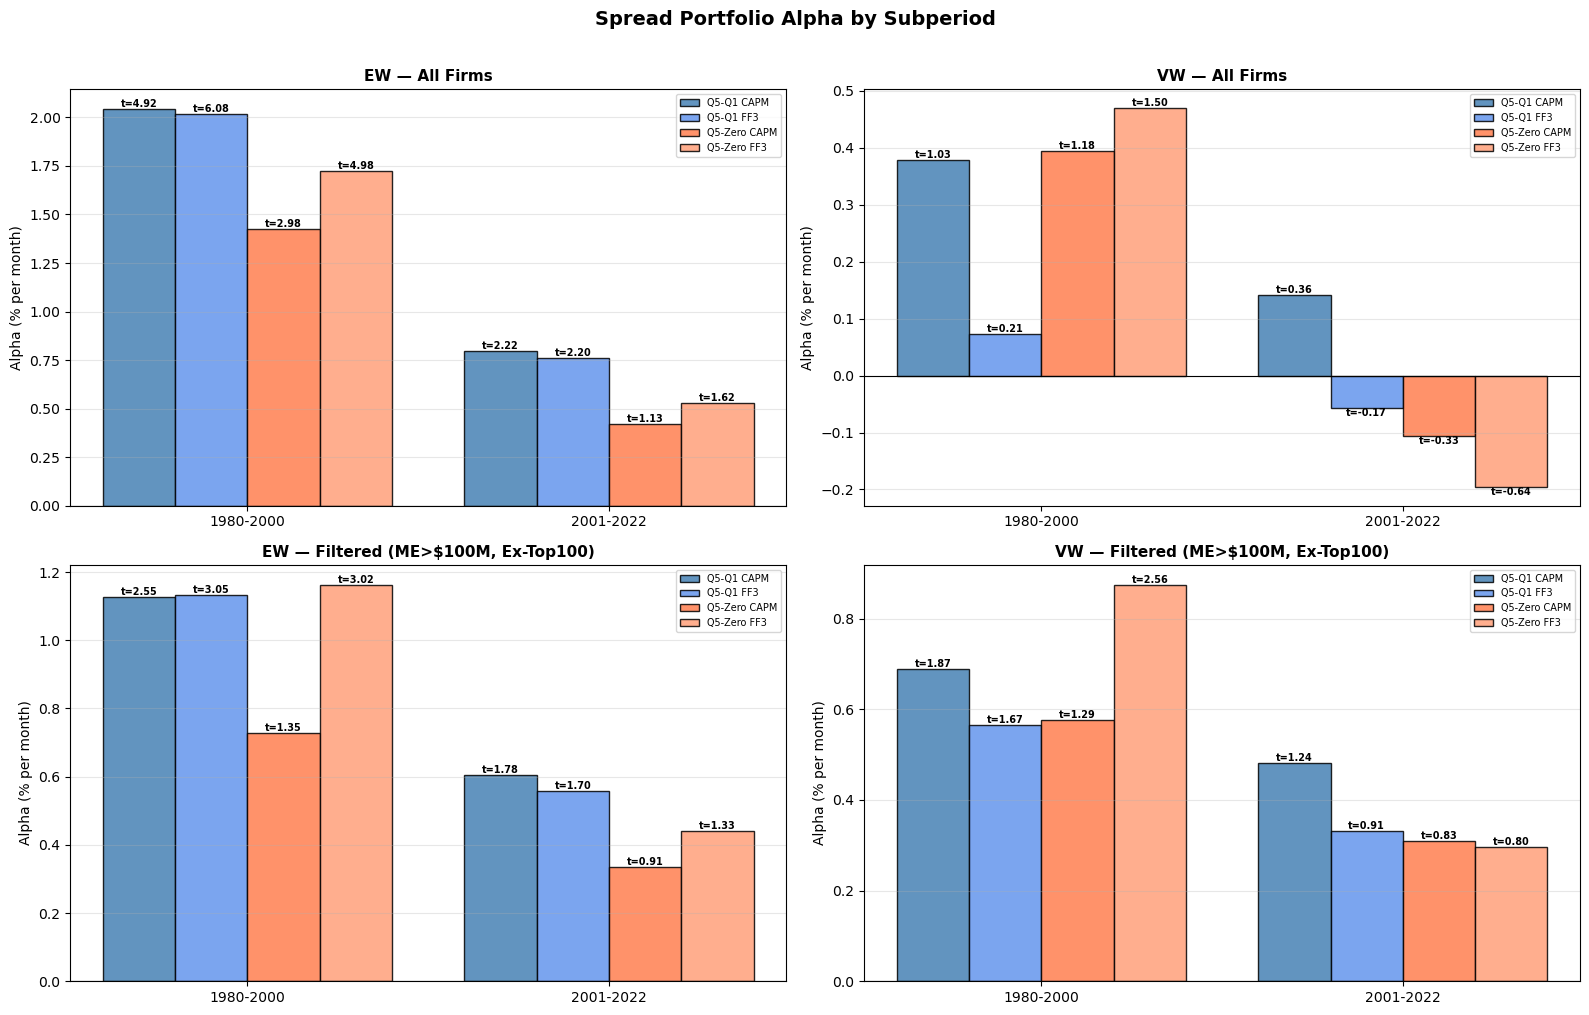

In [99]:
# === GRAPH 1: Spread Portfolio Alpha Across Subperiods — Both Samples ===
sample_names = list(all_results.keys())
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
period_names = list(periods.keys())
xp = np.arange(len(period_names))
w = 0.2

for row, sample_name in enumerate(sample_names):
    for col, wt in enumerate(['EW', 'VW']):
        ax = axes[row, col]
        capm_df = all_results[sample_name][wt]['capm']
        ff3_df = all_results[sample_name][wt]['ff3']

        for i, (sp, color_c, color_f) in enumerate([
            ('Q5-Q1', 'steelblue', 'cornflowerblue'),
            ('Q5-Zero', 'coral', 'lightsalmon')
        ]):
            capm_a = [float(capm_df.loc[f'{sp} ({p})', 'Alpha (%)']) for p in period_names]
            ff3_a = [float(ff3_df.loc[f'{sp} ({p})', 'Alpha (%)']) for p in period_names]
            capm_t = [float(capm_df.loc[f'{sp} ({p})', 'Alpha t']) for p in period_names]
            ff3_t = [float(ff3_df.loc[f'{sp} ({p})', 'Alpha t']) for p in period_names]

            offset_c = -1.5*w + i*2*w
            offset_f = -0.5*w + i*2*w
            bars1 = ax.bar(xp + offset_c, capm_a, w, label=f'{sp} CAPM', color=color_c, edgecolor='black', alpha=0.85)
            bars2 = ax.bar(xp + offset_f, ff3_a, w, label=f'{sp} FF3', color=color_f, edgecolor='black', alpha=0.85)

            for bar, t in zip(bars1, capm_t):
                va = 'bottom' if bar.get_height() >= 0 else 'top'
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f't={t:.2f}',
                        ha='center', va=va, fontsize=7, fontweight='bold')
            for bar, t in zip(bars2, ff3_t):
                va = 'bottom' if bar.get_height() >= 0 else 'top'
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f't={t:.2f}',
                        ha='center', va=va, fontsize=7, fontweight='bold')

        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        ax.set_xticks(xp); ax.set_xticklabels(period_names)
        ax.set_title(f'{wt} — {sample_name}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Alpha (% per month)')
        ax.legend(fontsize=7, loc='best'); ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Spread Portfolio Alpha by Subperiod', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

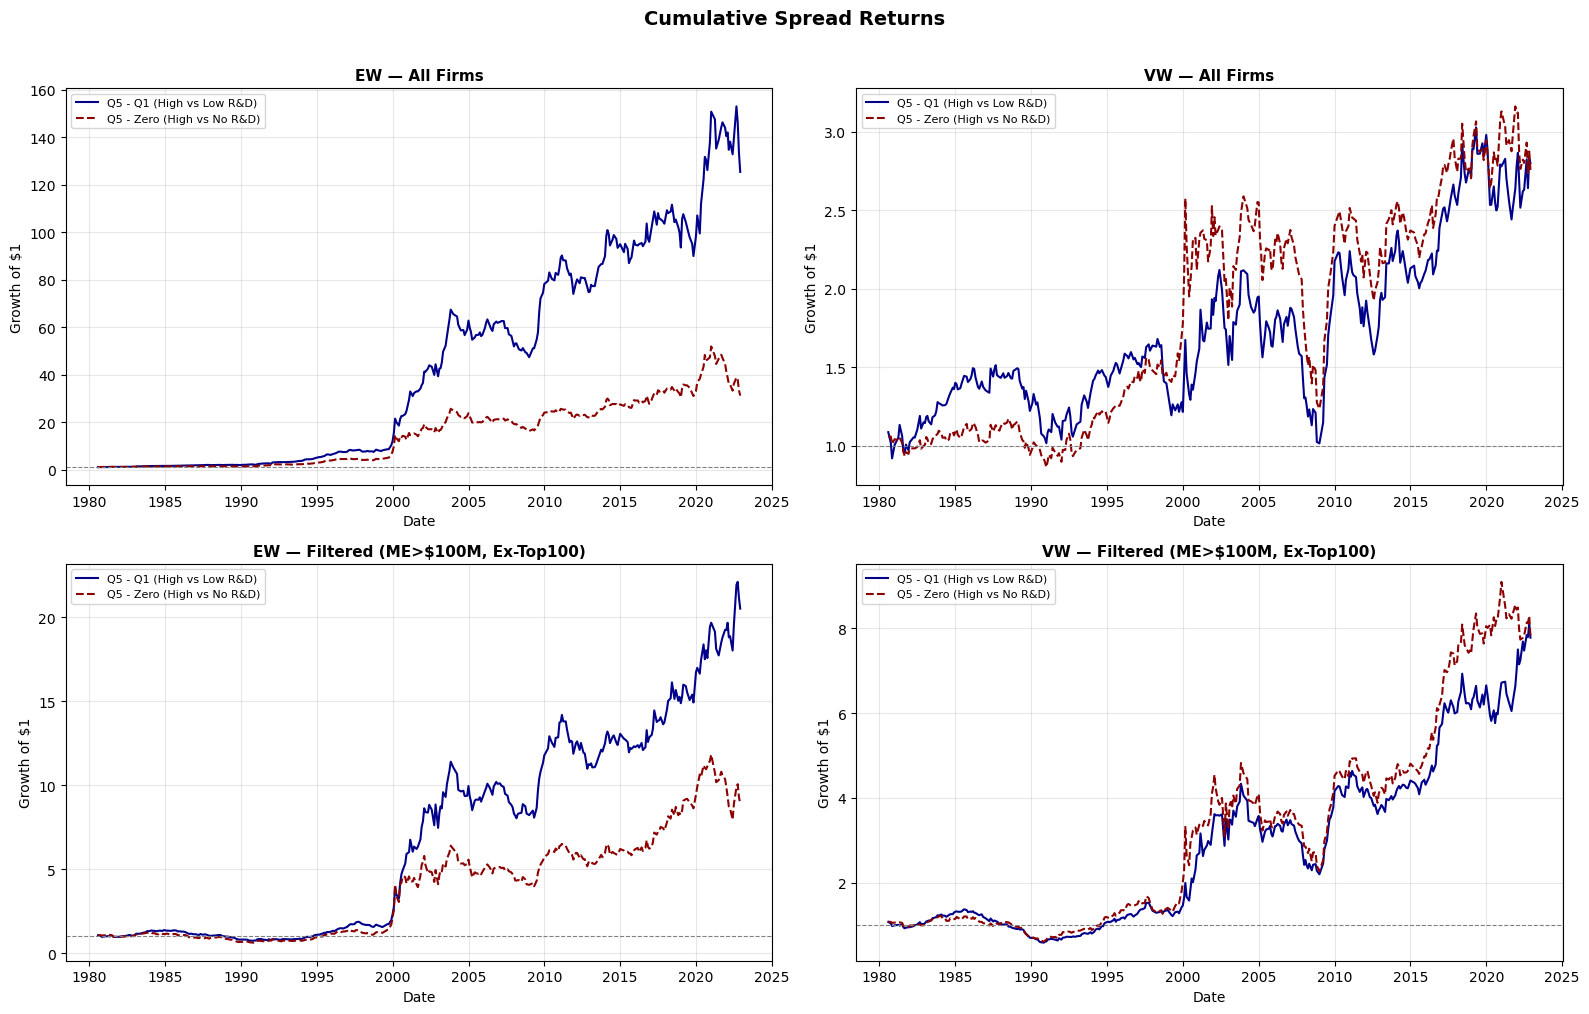

In [100]:
# === GRAPH 2: Cumulative Return of Spread Portfolios — Both Samples ===
sample_names = list(samples.keys())
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, sample_name in enumerate(sample_names):
    for col, wt in enumerate(['EW', 'VW']):
        ax = axes[row, col]
        wt_data = samples[sample_name][wt]
        
        for spread_col, label, color, ls in [
            ('Q5-Q1', 'Q5 - Q1 (High vs Low R&D)', 'darkblue', '-'),
            ('Q5-Zero', 'Q5 - Zero (High vs No R&D)', 'darkred', '--')
        ]:
            series = wt_data[['date', spread_col]].dropna().sort_values('date')
            cumret = (1 + series[spread_col].astype(float)).cumprod()
            ax.plot(series['date'].values, cumret.values, linewidth=1.5, color=color, linestyle=ls, label=label)

        ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
        ax.set_title(f'{wt} — {sample_name}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Growth of $1')
        ax.set_xlabel('Date')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('Cumulative Spread Returns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()